In [1]:
import sys
from pathlib import Path

# Get the absolute path of the project root (one level above notebooks/)
project_root = Path().resolve().parent

# Add "src/" to sys.path
sys.path.append(str(project_root / "src"))

In [2]:
# Download mrc file from CZII source
from cryoet_data_portal import Client, Tomogram

client = Client()

tomogram = Tomogram.get_by_id(client, 18961)
# tomogram.download_mrcfile()

In [3]:
# Open the MRC file

import mrcfile
import numpy as np
import os

# Load the cryo-et data
my_data_path = "../data/experimental"
# file_name = "TS_105_5.mrc"
# file_name = "TS_105_7.mrc"
# file_name = "27042022_BrnoKrios_Arctis_grid9_hGIS_Position_44.mrc"
# file_name = "AN-28752.mrc"
# file_name = "73_128_normalized.mrc"
# file_name = "090_TS49_S3_normalized.mrc"
# file_name = "090_TS49_S3_denoised_normalized.mrc"
# file_name = "Dataset2_Final.mrc"
file_name = "M3_EMTomo.rec"
# file_path = os.path.join(my_data_path, file_name)
# file_path = os.path.join(my_data_path, "raw", file_name)
file_path = os.path.join(my_data_path, "raw/venkatraman", file_name)

with mrcfile.open(file_path, permissive=True) as mrc:
    cryoet_data = mrc.data  # 3D array containing intensity

    # Access header information
    print("Data shape:", mrc.data.shape)  # Dimensions of the data
    print("Voxel size (angstroms):", mrc.voxel_size)  # Voxel size if available
    print("Map origin:", mrc.header.origin)  # Origin of the map
    print("Pixel spacing:", mrc.voxel_size)  # Pixel spacing for each axis
    print("Minimum and maximum density:", mrc.header.dmin, mrc.header.dmax)
    print("Mean density:", mrc.header.dmean)

    # Other specific header fields
    print("Number of columns, rows, and sections:", mrc.header.nx, mrc.header.ny, mrc.header.nz)
    print("Data mode:", mrc.header.mode)  # Data type (e.g., byte, float)
    print("Cell dimensions (angstroms):", mrc.header.cella)  # Cell dimensions
    print("Cell angles:", mrc.header.cellb)  # Cell angles

Data shape: (153, 2000, 2000)
Voxel size (angstroms): (16.2, 16.2, 16.2)
Map origin: (-0.0, -1215.0, -0.0)
Pixel spacing: (16.2, 16.2, 16.2)
Minimum and maximum density: -128.0 127.0
Mean density: 37.600693
Number of columns, rows, and sections: 2000 2000 153
Data mode: 0
Cell dimensions (angstroms): (32400.002, 32400.002, 2478.6)
Cell angles: (90.0, 90.0, 90.0)


In [247]:
# OLD VERSION
# Crop and downsample data

import skimage.measure
import numpy as np
from skimage.transform import resize

# Crop the cryo-ET data
cropped = cryoet_data[z_start:z_end, y_start:y_end, x_start:x_end]

# Downsample using local mean in blocks
factor = 1
downsampled = skimage.measure.block_reduce(cropped, block_size=(factor, factor, factor), func=np.mean)

# Flip sign
downsampled = - downsampled

# Add padding to make the calculatioin space even in each direction

# Get current shape
Z, Y, X = downsampled.shape
target_size = max(Y, X)  # Make it cubic in Y/X/Z

# Calculate padding needed for Z
pad_total = target_size - Z
pad_before = pad_total // 2
pad_after = pad_total - pad_before

# Pad the Z-axis with zeros on both sides
padded = np.pad(downsampled,
                pad_width=((pad_before, pad_after), (0, 0), (0, 0)), 
                mode='constant', constant_values=0)

print("Downsampled shape:", downsampled.shape)
print("Padded shape:  ", padded.shape)

# Resize to (64, 64, 64)
GRID_SIZE = 64
resized = resize(padded, (GRID_SIZE, GRID_SIZE, GRID_SIZE), mode='reflect', anti_aliasing=True)

print("Resized shape:  ", resized.shape)

# Global normalization over entire volume
intensity_max = 2.
global_min = np.min(resized)
global_max = np.max(resized)
normalized = (resized - global_min) / (global_max - global_min)
normalized *= intensity_max
normalized[normalized > 1.0] = 1.0

print("Normalized shape:", normalized.shape)


Downsampled shape: (150, 700, 700)
Padded shape:   (700, 700, 700)
Resized shape:   (64, 64, 64)
Normalized shape: (64, 64, 64)


In [4]:
import skimage.measure
import numpy as np
from skimage.transform import resize

def downsample(x_start, x_end, y_start, y_end, z_start, z_end, k=1, GRID_SIZE = 64, intensity_max = 2.0):
    
    # --- Crop ---
    cropped = cryoet_data[z_start:z_end, y_start:y_end, x_start:x_end]
    
    # --- Downsample ---
    factor = 1
    downsampled = skimage.measure.block_reduce(
        cropped, block_size=(factor, factor, factor), func=np.mean
    ).astype(np.float32)
    
    downsampled = -downsampled
    
    # --- Pad Z to match max(Y, X) ---
    Z, Y, X = downsampled.shape
    target_size = max(Y, X)
    
    pad_total = target_size - Z
    pad_before = pad_total // 2
    pad_after  = pad_total - pad_before
    
    padded = np.pad(
        downsampled,
        pad_width=((pad_before, pad_after), (0, 0), (0, 0)),
        mode="constant",
        constant_values=0,
    )
    
    # Mask: 1 where original data exists, 0 where padding is
    mask = np.ones_like(downsampled, dtype=np.uint8)
    mask_padded = np.pad(
        mask,
        pad_width=((pad_before, pad_after), (0, 0), (0, 0)),
        mode="constant",
        constant_values=0,
    )

    print("Downsampled shape:", downsampled.shape)
    print("Padded shape:  ", padded.shape)
    
    # IMPORTANT: use constant mode + cval=0 so resize doesn't reflect data into padding
    resized = resize(
        padded, (GRID_SIZE, GRID_SIZE, GRID_SIZE),
        mode="constant", cval=0,
        anti_aliasing=True,
        preserve_range=True,
    )
    
    # Resize mask with nearest-neighbor (order=0) so it stays binary-ish
    mask_resized = resize(
        mask_padded.astype(np.float32), (GRID_SIZE, GRID_SIZE, GRID_SIZE),
        mode="constant", cval=0,
        anti_aliasing=False,
        order=0,
        preserve_range=True,
    ) > 0.5

    print("Resized shape:  ", resized.shape)
    
    # Hard-zero padded region after resize
    resized[~mask_resized] = 0.0
    
    # --- Normalize (option: normalize using only real voxels) ---
    intensity_max = 2.0
    real_vals = resized[mask_resized]
    global_min = real_vals.min()
    global_max = real_vals.max()
    
    normalized = (resized - global_min) / (global_max - global_min + 1e-12)
    normalized *= intensity_max
    normalized = np.clip(normalized, 0.0, 1.0)
    
    # --- Shrink valid region by 1 z-layer on both ends ---
    valid_z = np.where(mask_resized.any(axis=(1, 2)))[0]
    if valid_z.size > 0:
        zmin, zmax = valid_z[0], valid_z[-1]
        mask_resized[zmin:zmin+k, :, :] = False
        mask_resized[zmax-k+1:zmax+1, :, :] = False
    
    # Enforce zero using the updated mask (do this at the very end)
    normalized[~mask_resized] = 0.0

    print("Normalized shape:", normalized.shape)
    return normalized


In [9]:
import skimage.measure
import numpy as np
from skimage.transform import resize

def downsample_elong(x_start, x_end, y_start, y_end, z_start, z_end, GRID_SIZE = 64, intensity_max = 2.0):

    # -------------------
    # Crop
    # -------------------
    # cropped = cryoet_data[z_start:z_end, y_start:y_end, x_start:x_end]

    cropped = cryoet_data[z_start:z_end, y_start:y_end, x_start:x_end].copy()

    # cropped[cropped > 50] = 0

    vmin = 0.23
    vmax = 21.8
    scaled = (cropped - vmin) / (vmax - vmin)
    scaled = np.clip(scaled, 0.0, 1.0)    
    cropped = scaled
    
    # -------------------
    # Downsample
    # -------------------
    factor = 1
    downsampled = skimage.measure.block_reduce(
        cropped,
        block_size=(factor, factor, factor),
        func=np.mean
    ).astype(np.float32)
    
    # Flip sign
    downsampled = -downsampled
    
    print("Downsampled shape:", downsampled.shape)
    
    # -------------------
    # Resize NON-padded data first
    # -------------------
    
    resized = resize(
        downsampled,
        (GRID_SIZE, GRID_SIZE, GRID_SIZE),
        mode="constant",
        cval=0,
        anti_aliasing=True,
        preserve_range=True,
    ).astype(np.float32)
    
    print("Resized shape:", resized.shape)
    
    # -------------------
    # Now pad AFTER resize
    # (example: pad Z only, symmetric)
    # -------------------
    Z, Y, X = resized.shape
    target_size = max(Y, X)
    
    pad_total = target_size - Z
    pad_before = pad_total // 2
    pad_after  = pad_total - pad_before
    
    padded = np.pad(
        resized,
        pad_width=((pad_before, pad_after), (0, 0), (0, 0)),
        mode="constant",
        constant_values=0,
    )
    
    print("Final padded shape:", padded.shape)
    
    # -------------------
    # Normalize (padding stays exactly zero)
    # -------------------    
    # Normalize using only non-zero voxels
    valid = padded != 0
    
    vmin = padded[valid].min()
    vmax = padded[valid].max()
    
    normalized = np.zeros_like(padded, dtype=np.float32)
    normalized[valid] = (padded[valid] - vmin) / (vmax - vmin + 1e-12)
    normalized[valid] *= intensity_max
    normalized[normalized > 1.0] = 1.0
    
    print("Normalized shape:", normalized.shape)

    return normalized

In [20]:
# Define crop range in z, y, x
# z_start, z_end = 0, 150
# y_start, y_end = 900, 1250
# x_start, x_end = 150, 500

z_start, z_end = 0, 150
y_start, y_end = 100, 800
x_start, x_end = 1200, 1900

# normalized = downsample(x_start, x_end, y_start, y_end, z_start, z_end)
normalized = downsample_elong(x_start, x_end, y_start, y_end, z_start, z_end, GRID_SIZE=128)

Downsampled shape: (150, 700, 700)
Resized shape: (128, 128, 128)
Final padded shape: (128, 128, 128)
Normalized shape: (128, 128, 128)


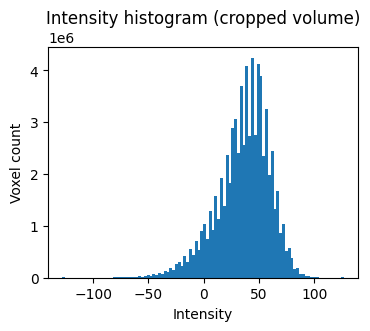

In [77]:
import matplotlib.pyplot as plt

cropped = cryoet_data[z_start:z_end, y_start:y_end, x_start:x_end]

plt.figure(figsize=(4, 3))
plt.hist(cropped.ravel(), bins=100)
# plt.hist(normalized.ravel(), bins=100)
plt.xlabel("Intensity")
plt.ylabel("Voxel count")
plt.title("Intensity histogram (cropped volume)")
plt.show()


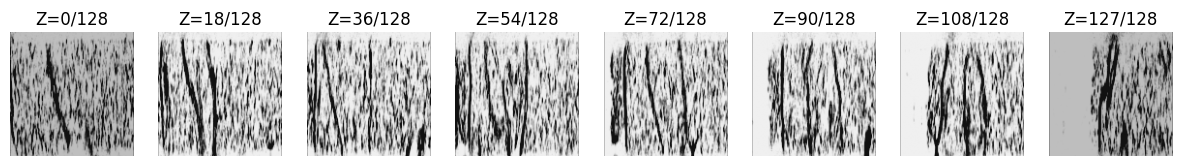

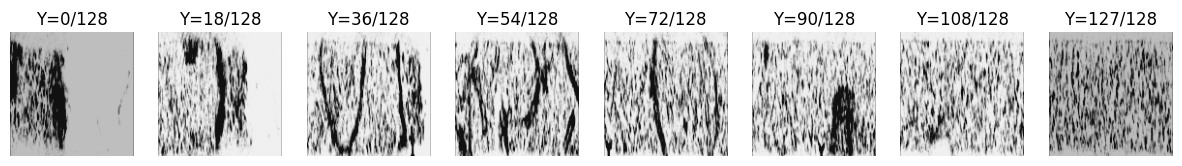

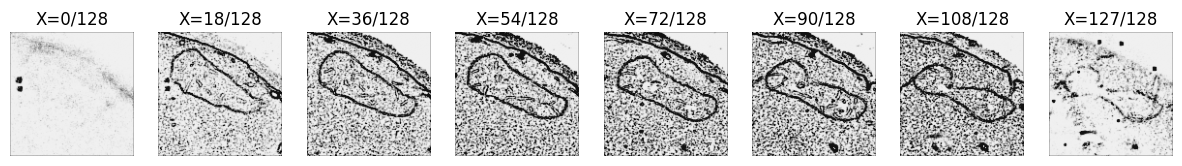

In [21]:
# Visualize data
from data_generation.mesh_to_cryoet import plot_multiple_slices

n_slices = 8
threshold = 0.8
threshold = None

visualize = normalized
# visualize = cryoet_data

plot_multiple_slices(visualize, axis='z', num_slices=n_slices, thre=threshold)
plot_multiple_slices(visualize, axis='y', num_slices=n_slices, thre=threshold)
plot_multiple_slices(visualize, axis='x', num_slices=n_slices, thre=threshold)

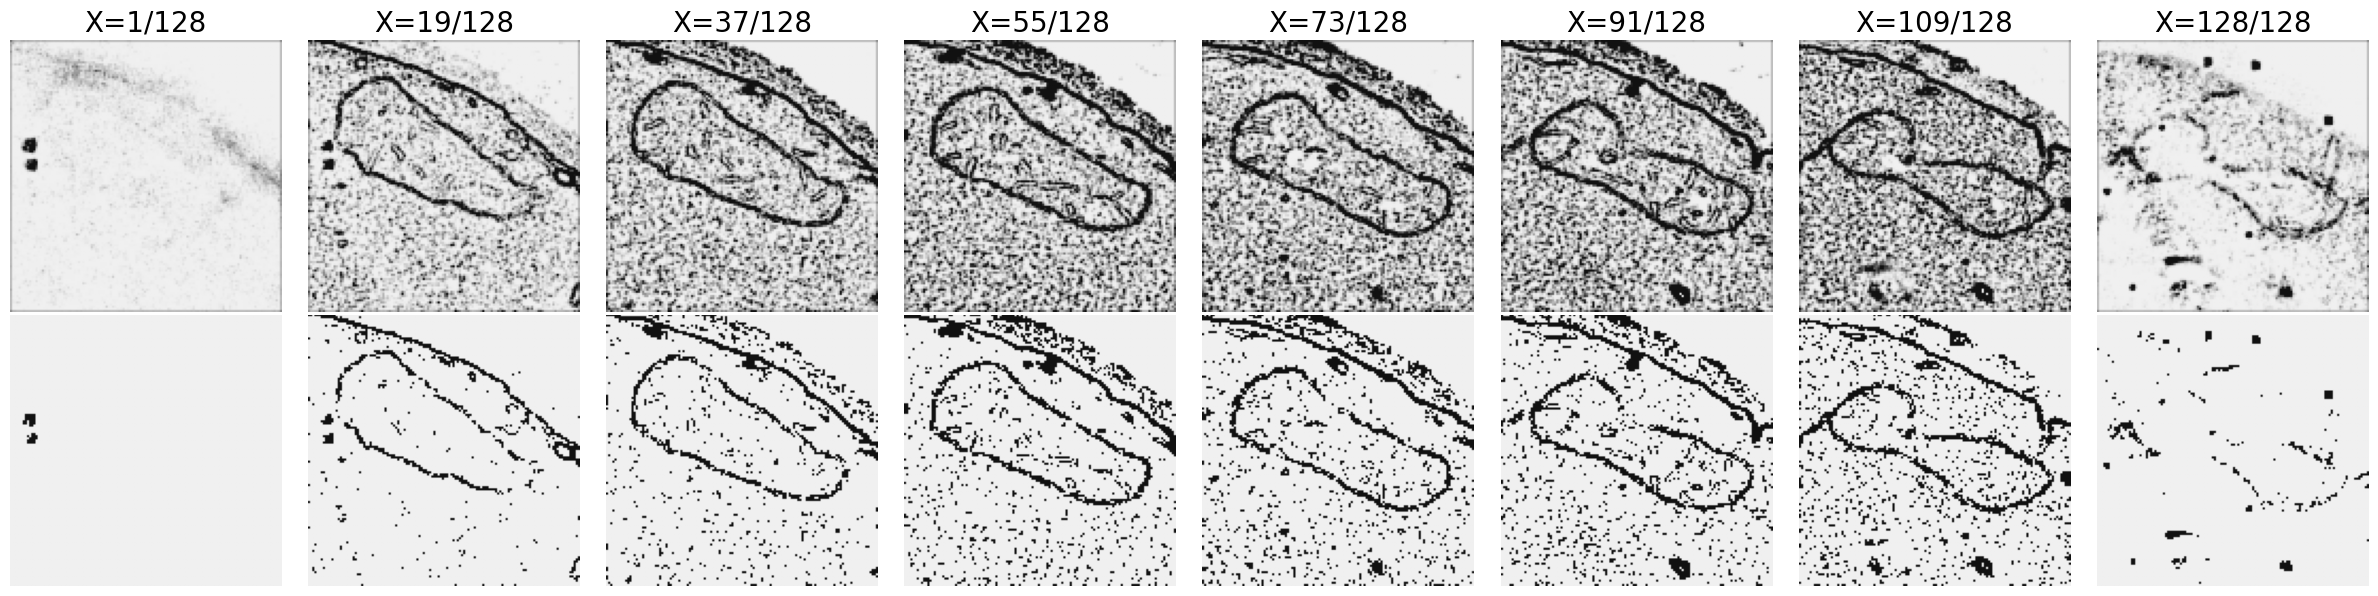

In [22]:
# Visualize slices

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Parameters
n_slices = 8
threshold = 0.8

visualize = normalized

# Evenly spaced Z indices
z_indices = np.linspace(0, visualize.shape[0] - 1, n_slices, dtype=int)

# Plot
fig, axes = plt.subplots(2, n_slices, figsize=(3 * n_slices, 6))
custom_gray = LinearSegmentedColormap.from_list('custom_gray', ['#f0f0f0', '#111111'])

for i, z_index in enumerate(z_indices):
    norm_slice = visualize[z_index, :, :]
    binary_mask = np.where(norm_slice > threshold, 1, 0)
    # binary_mask = (norm_slice > threshold).astype(np.uint8)

    # Row 1: normalized slice
    # axes[0, i].imshow(norm_slice, cmap='gray')
    axes[0, i].imshow(norm_slice, cmap=custom_gray)
    axes[0, i].set_title(f'X={z_index+1}/{visualize.shape[0]}', fontsize=20)
    axes[0, i].axis('off')

    # Row 2: thresholded mask
    axes[1, i].imshow(binary_mask, cmap=custom_gray)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [23]:
# Save downsampled data

data_output = normalized

data_path = "../data/experimental/"
out_file_name = "venk_2_elong_crop.mrc"
# output_file = os.path.join(my_data_path, "downsampled", file_name)
output_file = os.path.join(data_path, "downsampled", out_file_name)
with mrcfile.new(output_file, overwrite=True) as mrc:
    mrc.set_data(data_output.astype(np.float32))

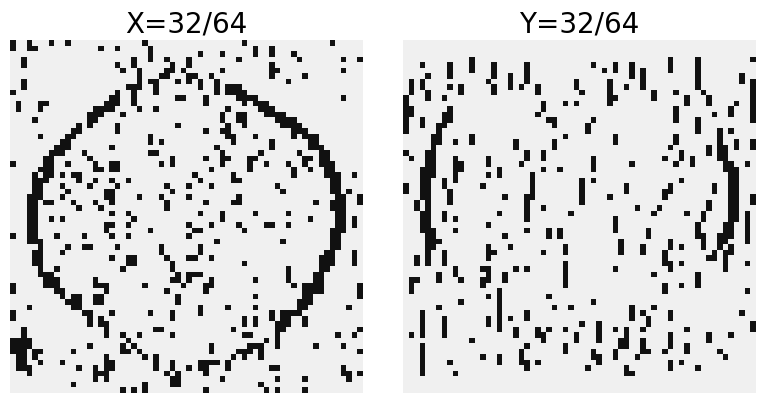

In [8]:
# Plot 2 figures

from pinn.cryoet_io import load_mrc_data
from data_generation.mesh_to_cryoet import plot_single_slice

import matplotlib.pyplot as plt

mrc_file_path = "../data/experimental/downsampled/TS_105_7.mrc"
pseudo_cryoET = load_mrc_data(mrc_file_path, grid_size=64)

thre = None
thre = 0.8

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_single_slice(pseudo_cryoET, ax=axes[0], axis='x', thre=thre)  # X-direction
plot_single_slice(pseudo_cryoET, ax=axes[1], axis='y', thre=thre)  # Y-direction

plt.tight_layout()
plt.show()


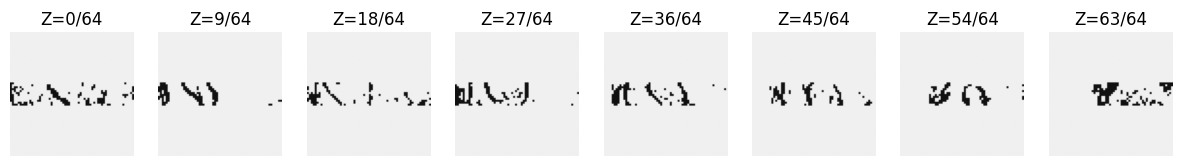

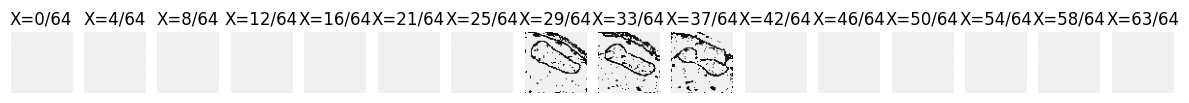

In [291]:
# Plot multiple slices

from pinn.cryoet_io import load_mrc_data
from data_generation.mesh_to_cryoet import plot_single_slice, plot_multiple_slices

import matplotlib.pyplot as plt

mrc_file_path = "../data/experimental/downsampled/venk_2.mrc"
tomogram = load_mrc_data(mrc_file_path, grid_size=64)

# tomogram = 1-tomogram

thre = None
thre = 0.8

plot_multiple_slices(tomogram, axis='z', num_slices=8, thre=thre)
plot_multiple_slices(tomogram, axis='x', num_slices=16, thre=thre)


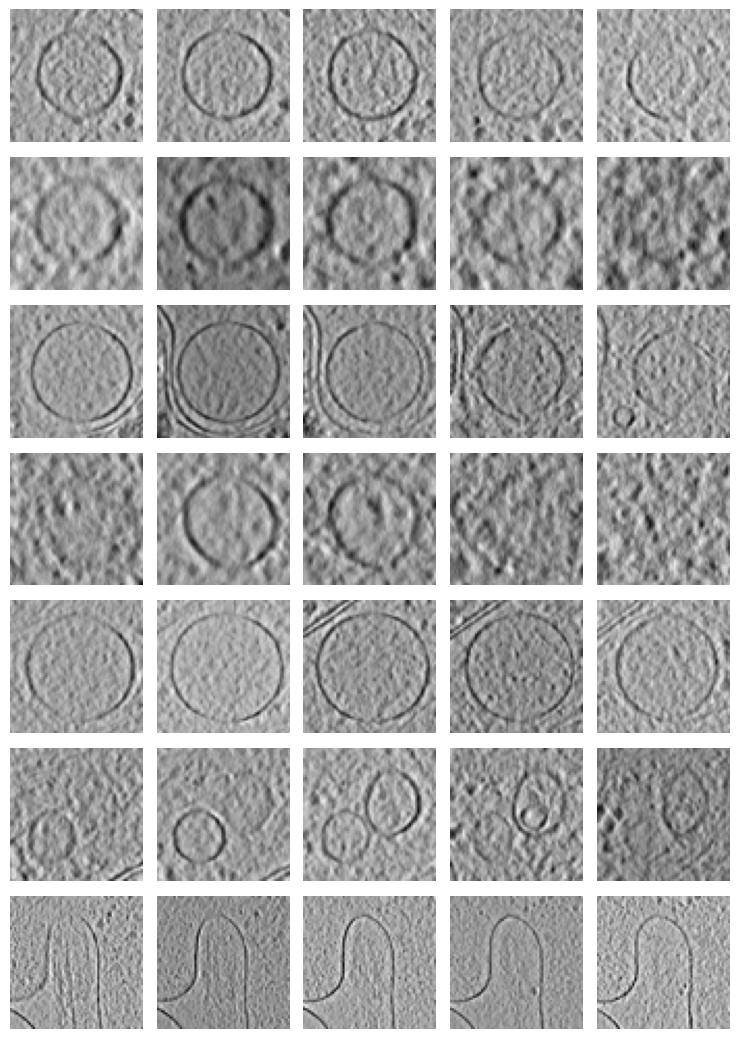

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp


GRID_SIZE = 64
thre = None
shape_list = ["S1", "S2", "S3", "S4", "S5", "SS1", "E1"]
slice_list = [20, 26, 32, 38, 44]

# Load input data
input_data = {}
for shape in shape_list:
    input_file = f"../data/experimental/raw/jake/74_{shape}.mrc"
    if os.path.exists(input_file):
        volume = load_mrc_data(input_file, grid_size=GRID_SIZE)
        volume = 1 - volume
        volume = np.flip(volume, axis=1)
        input_data[shape] = volume
        
# Plot 
n = len(slice_list)    # slice columns
m = len(shape_list)    # shape rows

fig = plt.figure(figsize=(1.5*n, 1.5*m))

for i, shape in enumerate(shape_list): # rows
    data = input_data.get(shape, None)

    for j, slice_id in enumerate(slice_list): # columns
        ax = fig.add_subplot(m, n, i * n + j + 1)

        if data is not None:
            plot_single_slice(data, ax=ax, axis="x", slice_index=slice_id, thre=thre, show_title=False) 
        else:
            ax.axis("off")

    
plt.tight_layout()
plt.savefig(f"../outputs/figs/sync/experiment/jake_raw.png", dpi=600, bbox_inches="tight")
plt.show()